<div dir="rtl">

# מטלה 2 — טיפול בנתונים חסרים, מודל פרוגנוסטי ודירוג סיכונים

**דאטה:** MIMIC Demo | **מטרה:** Prolonged ICU Stay (שהייה ב-ICU באחוזון 75 ומעלה).

## עקרונות מתודולוגיים (מנחים את כל המחברת)
- **מניעת דליפה:** כל השלמה/סקיילינג/קידוד נלמדים על ה-train בלבד בתוך `Pipeline`, ומוחלים על ה-test.
- `icu_los` והמזהים מושמטים מהפיצ'רים — `icu_los` מגדיר את המטרה.
- **שחזוריות:** `SEED=42` קבוע בכל מקום (פיצול, יצירת חוסר, מודלים).
- **גרפים:** תוויות באנגלית כדי שהעברית לא תתהפך; כל הניתוח המילולי בעברית בטבלאות וב-Markdown.

</div>

In [1]:
# === תא 0: הגדרות, טעינה ועזרי תצוגה ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})

DATA_FILENAME = "MIMIC_data_demo.xlsx"
RAW_URL = ("https://raw.githubusercontent.com/Roybin12/"
           "medical-machine-learning-/main/MIMIC_data_demo.xlsx")

def find_data_path(filename=DATA_FILENAME, max_up=5):
    here = Path.cwd().resolve()
    for folder in [here, *here.parents][:max_up + 1]:
        if (folder / filename).exists():
            return folder / filename
    return None

def load_raw_data():
    """טוען מה-repo המקומי; אם לא נמצא — נופל ל-GitHub raw. רץ מכל מחשב."""
    path = find_data_path()
    return pd.read_excel(path if path is not None else RAW_URL)

def rtl(df):
    """מציג DataFrame בכיוון ימין-לשמאל (קריא בעברית)."""
    sty = df.style.set_table_styles(
        [{"selector": "", "props": [("direction", "rtl")]},
         {"selector": "th, td", "props": [("text-align", "right")]}])
    try:
        sty = sty.hide(axis="index")
    except Exception:
        pass
    return sty

df_raw = load_raw_data()
display(rtl(pd.DataFrame({"שורות": [df_raw.shape[0]], "עמודות": [df_raw.shape[1]]})))

שורות,עמודות
4559,57


<div dir="rtl">

## שלב 1 — יצירת משתנה המטרה (Outcome)

**הגדרה:** `prolonged_icu = 1` אם `icu_los` ≥ אחוזון 75, אחרת 0.
**החלטה:** בוחרים 13 משתנים תואמי-מטלה ומשמיטים `icu_los` והמזהים מהפיצ'רים (מניעת דליפה).

</div>

מדד,ערך
סף icu_los (אחוזון 75),5.865 ימים
"סה""כ רשומות",4559
חיוביים (n+),1140
שליליים,3419
אחוז חיוביים,25.0%


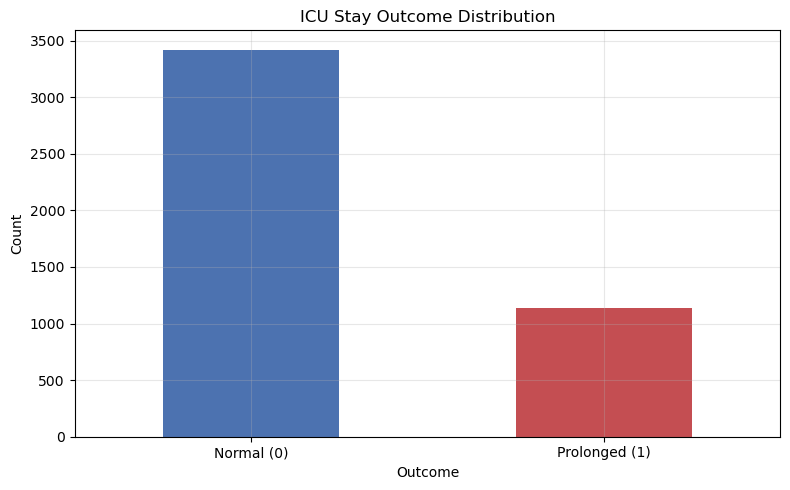

In [2]:
# === שלב 1: משתנה המטרה ובחירת פיצ'רים ===
rename_map = {
    "age": "age", "gender": "gender", "ethnicity": "ethnicity",
    "first_service": "service_first", "vent": "vent",
    "heartrate_mean": "mean_heartrate", "sysbp_mean": "mean_sysbp",
    "resprate_mean": "mean_resprate", "tempc_mean": "mean_tempc",
    "spo2_mean": "mean_spo2", "glucose_mean": "mean_glucose",
    "creatinine_max": "max_creatinine", "wbc_mean": "mean_wbc",
}
FEATURES = list(rename_map.values())

TARGET_PCTL = 0.75
los_threshold = df_raw["icu_los"].quantile(TARGET_PCTL)
df = df_raw.rename(columns=rename_map)[FEATURES].copy()
df["prolonged_icu"] = (df_raw["icu_los"] >= los_threshold).astype(int)

n_total = len(df); n_pos = int(df["prolonged_icu"].sum())
target_summary = pd.DataFrame({
    "מדד": ["סף icu_los (אחוזון 75)", "סה\"כ רשומות", "חיוביים (n+)",
            "שליליים", "אחוז חיוביים"],
    "ערך": [f"{los_threshold:.3f} ימים", n_total, n_pos,
            n_total - n_pos, f"{n_pos / n_total * 100:.1f}%"],
})
display(rtl(target_summary))

# גרף — תוויות באנגלית
counts = df["prolonged_icu"].value_counts().sort_index()
ax = counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], rot=0)
ax.set_title("ICU Stay Outcome Distribution")
ax.set_xlabel("Outcome"); ax.set_ylabel("Count")
ax.set_xticklabels(["Normal (0)", "Prolonged (1)"])
plt.tight_layout(); plt.show()

<div dir="rtl">

**שאלה 1 — האם קיים חוסר איזון?**
כן, חוסר איזון מתון: ~25% חיוביים מול ~75% שליליים (נובע מהגדרת המטרה כרבע העליון).
נטפל בכך ע"י פיצול מרובד (stratify), `class_weight`, ודגש על PR-AUC ולא רק ROC-AUC.

</div>

<div dir="rtl">

## שלב 2 — יצירת נתונים חסרים (מלאכותיים)

שומרים עותק אמת (`df_original`) לפני ההחסרה, ומחסירים רק תאים שכרגע **קיימים** (כדי שתהיה אמת להשוואה בשלב 5).
- `mean_heartrate`: 10% אקראי → **MCAR**.
- `max_creatinine`: גיל<70 → 30% חסר ; גיל≥70 → 5% חסר → **MAR** (תלוי בגיל הנצפה).
שומרים מסכות של התאים שהוחסרו מלאכותית בלבד.

</div>

In [3]:
# === שלב 2: הזרקת חוסר מבוקר ===
rng = np.random.default_rng(SEED)
df_original = df.copy()      # אמת — לפני ההחסרה
df_missing = df.copy()       # עליו נעבוד מכאן והלאה

# (א) mean_heartrate — MCAR 10% מהתאים הקיימים
hr_obs = df_missing.index[df_missing["mean_heartrate"].notna()]
hr_sel = rng.choice(hr_obs, size=int(round(0.10 * len(hr_obs))), replace=False)
df_missing.loc[hr_sel, "mean_heartrate"] = np.nan

# (ב) max_creatinine — MAR לפי גיל
for age_mask, rate in [(df_missing["age"] < 70, 0.30),
                       (df_missing["age"] >= 70, 0.05)]:
    grp = df_missing.index[age_mask & df_missing["max_creatinine"].notna()]
    sel = rng.choice(grp, size=int(round(rate * len(grp))), replace=False)
    df_missing.loc[sel, "max_creatinine"] = np.nan

# מסכות של תאים שהוחסרו מלאכותית בלבד (קיים באמת אך NaN עכשיו)
artif_mask = {c: df_original[c].notna() & df_missing[c].isna()
              for c in ["mean_heartrate", "max_creatinine"]}

summary = pd.DataFrame({
    "משתנה": ["mean_heartrate", "max_creatinine"],
    "תאים שהוחסרו": [int(artif_mask["mean_heartrate"].sum()),
                     int(artif_mask["max_creatinine"].sum())],
    "אחוז חוסר מלאכותי": [f"{artif_mask['mean_heartrate'].mean() * 100:.1f}%",
                          f"{artif_mask['max_creatinine'].mean() * 100:.1f}%"],
    "מנגנון": ["MCAR", "MAR (תלוי גיל)"],
    "נימוק": ["אקראי לחלוטין — לא תלוי בשום משתנה",
              "הסתברות החוסר תלויה בגיל הנצפה (גבוה מתחת ל-70)"],
})
display(rtl(summary))

# חוסר כולל (טבעי + מלאכותי) — כטבלה
total_missing = (df_missing[["mean_heartrate", "max_creatinine"]]
                 .isna().mean().mul(100).round(2)
                 .reset_index())
total_missing.columns = ["משתנה", "אחוז חוסר כולל"]
display(rtl(total_missing))

משתנה,תאים שהוחסרו,אחוז חוסר מלאכותי,מנגנון,נימוק
mean_heartrate,456,10.0%,MCAR,אקראי לחלוטין — לא תלוי בשום משתנה
max_creatinine,885,19.4%,MAR (תלוי גיל),הסתברות החוסר תלויה בגיל הנצפה (גבוה מתחת ל-70)


משתנה,אחוז חוסר כולל
mean_heartrate,10.000000
max_creatinine,19.460000


<div dir="rtl">

**שאלה 2 — האם מנגנון החוסר השפיע על בחירת ההשלמה?**
כן. ב-MCAR (heartrate) כמעט כל שיטה נותנת אומדן בלתי-מוטה.
ב-MAR (creatinine, תלוי גיל) השלמת ממוצע מטה את הערכים, ואילו MICE מתנה על הגיל ולכן צפויה להתאים טוב יותר.

</div>

<div dir="rtl">

## שלב 3 — ניתוח ראשוני של הנתונים (EDA)

מציגים מספר רשומות, שכיחות התוצאה החיובית, ושיעור החוסר לכל משתנה.
לאחר מכן שלושה גרפים, כל אחד עם **מטרה** ו**תובנה מרכזית** התורמות להבנת הנתונים ולבניית המודל.
ה-EDA מתבצע על `df_missing` (הנתונים שעליהם נעבוד בפועל).

</div>

In [4]:
# === שלב 3א: סטטיסטיקות בסיס ===
overview = pd.DataFrame({
    "מדד": ["מספר רשומות", "מספר משתנים (פיצ'רים)",
            "תוצאות חיוביות (n+)", "שכיחות תוצאה חיובית"],
    "ערך": [len(df_missing), len(FEATURES),
            int(df_missing["prolonged_icu"].sum()),
            f"{df_missing['prolonged_icu'].mean() * 100:.1f}%"],
})
display(rtl(overview))

# שיעור חוסר לכל משתנה (טבעי + מלאכותי), ממוין יורד
miss_rate = (df_missing[FEATURES].isna().mean().mul(100).round(2)
             .sort_values(ascending=False).reset_index())
miss_rate.columns = ["משתנה", "אחוז חוסר"]
display(rtl(miss_rate))

מדד,ערך
מספר רשומות,4559
מספר משתנים (פיצ'רים),13
תוצאות חיוביות (n+),1140
שכיחות תוצאה חיובית,25.0%


משתנה,אחוז חוסר
max_creatinine,19.460000
mean_heartrate,10.000000
mean_tempc,2.260000
mean_glucose,0.660000
mean_sysbp,0.180000
mean_spo2,0.020000
mean_resprate,0.020000
vent,0.000000
gender,0.000000
age,0.000000


<div dir="rtl">

### גרף 1 — שיעור שהייה ממושכת לפי הנשמה מלאכותית (vent)
**מטרה:** לזהות מנבא קליני חזק לפני בניית המודל.
**תובנה מרכזית:** בקרב מונשמים שיעור השהייה הממושכת ~37% מול ~10% בלא-מונשמים (פי ~3.8) — `vent` צפוי להיות מנבא דומיננטי.

</div>

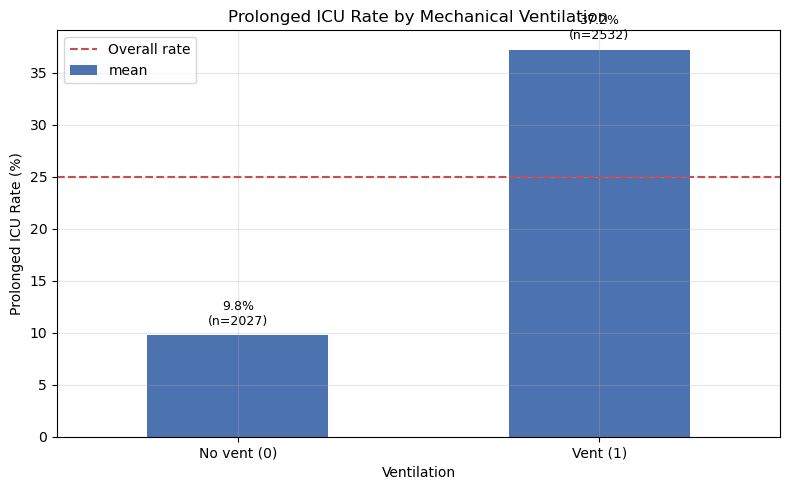

In [5]:
# === גרף 1: שיעור התוצאה לפי vent ===
rate_by_vent = df_missing.groupby("vent")["prolonged_icu"].agg(["mean", "size"])
ax = (rate_by_vent["mean"] * 100).plot(kind="bar", color="#4C72B0", rot=0)
ax.axhline(df_missing["prolonged_icu"].mean() * 100, color="#C44E52",
           linestyle="--", label="Overall rate")
ax.set_title("Prolonged ICU Rate by Mechanical Ventilation")
ax.set_xlabel("Ventilation"); ax.set_ylabel("Prolonged ICU Rate (%)")
ax.set_xticklabels(["No vent (0)", "Vent (1)"])
for i, (m, n) in enumerate(zip(rate_by_vent["mean"], rate_by_vent["size"])):
    ax.text(i, m * 100 + 1, f"{m*100:.1f}%\n(n={n})", ha="center", fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()

<div dir="rtl">

### גרף 2 — שיעור החוסר של max_creatinine לפי קבוצת גיל
**מטרה:** לאפיין את מנגנון החוסר ולבסס את בחירת שיטת ההשלמה.
**תובנה מרכזית:** החוסר מרוכז בגיל<70 (~30%) מול ~5% בגיל≥70 → מנגנון **MAR** תלוי-גיל; השלמת ממוצע תטה את הקבוצה הצעירה, MICE (המתנה על הגיל) עדיף.

</div>

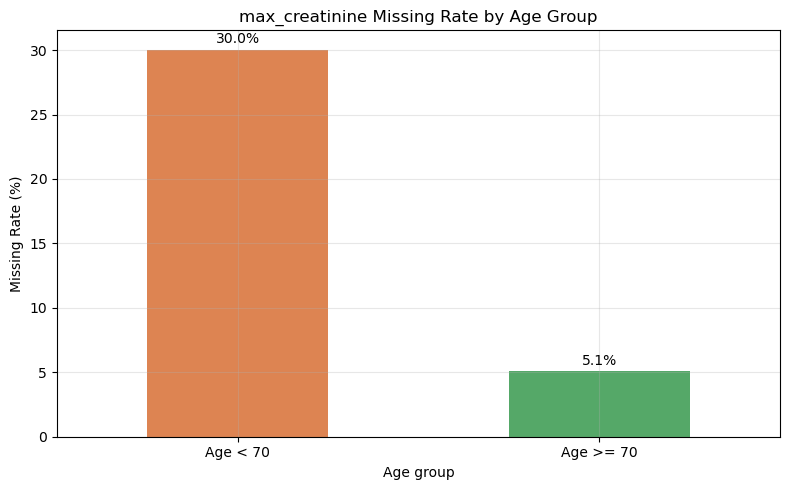

In [6]:
# === גרף 2: חוסר creatinine לפי קבוצת גיל (אישוש MAR) ===
age_band = np.where(df_missing["age"] < 70, "Age < 70", "Age >= 70")
miss_by_age = (df_missing["max_creatinine"].isna()
               .groupby(age_band).mean().mul(100))
miss_by_age = miss_by_age.reindex(["Age < 70", "Age >= 70"])
ax = miss_by_age.plot(kind="bar", color=["#DD8452", "#55A868"], rot=0)
ax.set_title("max_creatinine Missing Rate by Age Group")
ax.set_xlabel("Age group"); ax.set_ylabel("Missing Rate (%)")
for i, v in enumerate(miss_by_age):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
plt.tight_layout(); plt.show()

<div dir="rtl">

### גרף 3 — מטריצת קורלציות בין המשתנים המספריים
**מטרה:** לאתר מולטיקולינאריות ויתירות בין פיצ'רים (חשוב לפרשנות רגרסיה לוגיסטית).
**תובנה מרכזית:** הקורלציות מתונות (מקסימום ~0.36, דופק↔קצב נשימה) → אין מולטיקולינאריות חמורה, מקדמי הרגרסיה ניתנים לפרשנות ואין צורך להסיר משתנים.

</div>

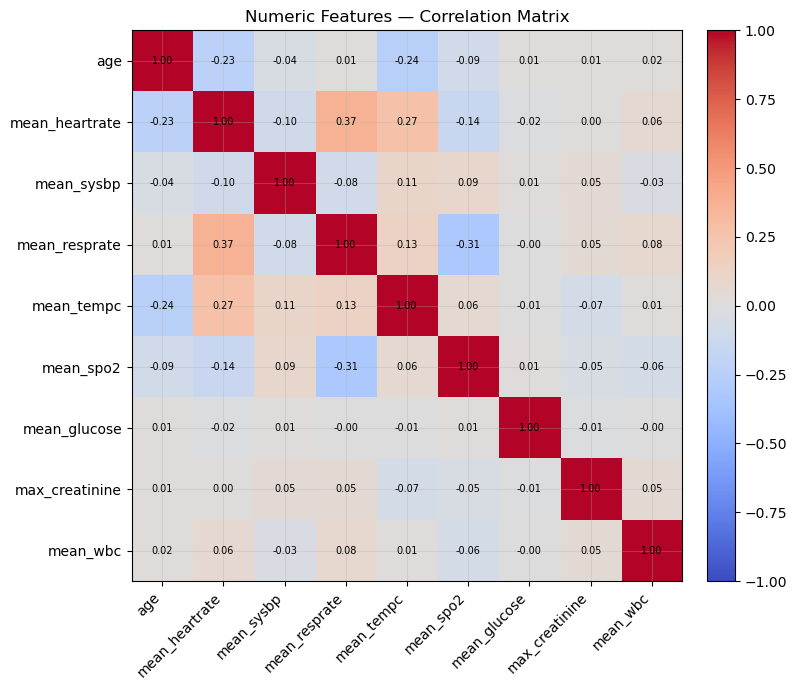

In [7]:
# === גרף 3: מטריצת קורלציות (משתנים מספריים) ===
num_cols = ["age", "mean_heartrate", "mean_sysbp", "mean_resprate",
            "mean_tempc", "mean_spo2", "mean_glucose", "max_creatinine", "mean_wbc"]
corr = df_missing[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right"); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="black")
ax.set_title("Numeric Features — Correlation Matrix")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

<div dir="rtl">

**שאלה 3 — איזו תובנה מה-EDA עשויה להשפיע על בניית המודל?**
החוסר ב-max_creatinine הוא MAR תלוי-גיל — לכן נעדיף MICE על פני ממוצע כדי לא להטות את הצעירים.
בנוסף, `vent` מנבא דומיננטי, והקורלציות המתונות מאפשרות פרשנות בטוחה של מקדמי הרגרסיה הלוגיסטית.

</div>

<div dir="rtl">

## שלב 4 — טיפול בנתונים חסרים

**עוגן מתודולוגי (מניעת דליפה):** קודם מפצלים `train/test` (מרובד לפי המטרה, `SEED=42`), ורק אז מאמנים את ההשלמה — `fit` על ה-train בלבד, `transform` על שניהם. כך ערכי ה-test לא מדליפים מידע.

מיישמים שתי שיטות על המשתנים המספריים:
- **Mean Imputation** — מילוי בממוצע העמודה (מה-train).
- **MICE** (`IterativeImputer`) — מודל איטרטיבי שמנבא כל משתנה חסר מתוך שאר המשתנים (כולל הגיל).

המשתנים הקטגוריאליים נטולי חוסר ולכן אינם דורשים השלמה.

</div>

In [9]:
# === שלב 4א: פיצול train/test (מרובד) ===
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, IterativeImputer

cat_cols = ["gender", "ethnicity", "service_first"]
num_cols = [c for c in FEATURES if c not in cat_cols]

X = df_missing[FEATURES]
y = df_missing["prolonged_icu"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)

split_summary = pd.DataFrame({
    "קבוצה": ["Train", "Test"],
    "רשומות": [len(X_train), len(X_test)],
    "אחוז חיוביים": [f"{y_train.mean() * 100:.1f}%", f"{y_test.mean() * 100:.1f}%"],
})
display(rtl(split_summary))

קבוצה,רשומות,אחוז חיוביים
Train,3419,25.0%
Test,1140,25.0%


In [10]:
# === שלב 4ב: השלמה — Mean ו-MICE, מאומנות על train בלבד ===
def impute_fit_transform(imputer, X_tr, X_te):
    """מאמן את ה-imputer על ה-train ומחיל על שניהם; מחזיר DataFrame מלא (מספרי+קטגוריאלי)."""
    im = clone(imputer).fit(X_tr[num_cols])
    tr = pd.DataFrame(im.transform(X_tr[num_cols]), columns=num_cols, index=X_tr.index)
    te = pd.DataFrame(im.transform(X_te[num_cols]), columns=num_cols, index=X_te.index)
    full_tr = pd.concat([tr, X_tr[cat_cols]], axis=1)[FEATURES]
    full_te = pd.concat([te, X_te[cat_cols]], axis=1)[FEATURES]
    return full_tr, full_te

imputers = {
    "Mean": SimpleImputer(strategy="mean"),
    "MICE": IterativeImputer(random_state=SEED, max_iter=10),
}

# Ximp["Mean"]["train"] / Ximp["MICE"]["test"] וכו' — לשימוש חוזר בשלבים 5-6
Ximp = {}
for name, imp in imputers.items():
    tr, te = impute_fit_transform(imp, X_train, X_test)
    Ximp[name] = {"train": tr, "test": te}

# אימות: לא נותרו ערכים חסרים אחרי ההשלמה
nan_check = pd.DataFrame([
    {"שיטה": name, "NaN ב-train": int(Ximp[name]["train"][num_cols].isna().sum().sum()),
     "NaN ב-test": int(Ximp[name]["test"][num_cols].isna().sum().sum())}
    for name in imputers
])
display(rtl(nan_check))

שיטה,NaN ב-train,NaN ב-test
Mean,0,0
MICE,0,0


In [11]:
# === שלב 4ג: יתרון/חיסרון לכל שיטה ===
methods_table = pd.DataFrame({
    "שיטת השלמה": ["Mean Imputation", "MICE"],
    "יתרון": [
        "פשוטה, מהירה, יציבה; טובה ל-MCAR",
        "מתנה על שאר המשתנים; מתאימה ל-MAR ושומרת על שונות"],
    "חיסרון": [
        "מצמצמת שונות, מתעלמת מקשרים, מטה ערכים ב-MAR",
        "איטית יותר, מורכבת, רגישה למודל ולמספר איטרציות"],
})
display(rtl(methods_table))

שיטת השלמה,יתרון,חיסרון
Mean Imputation,"פשוטה, מהירה, יציבה; טובה ל-MCAR","מצמצמת שונות, מתעלמת מקשרים, מטה ערכים ב-MAR"
MICE,מתנה על שאר המשתנים; מתאימה ל-MAR ושומרת על שונות,"איטית יותר, מורכבת, רגישה למודל ולמספר איטרציות"


<div dir="rtl">

**שאלה 4 — איזו שיטה צפויה להתאים טוב יותר למנגנון שזיהיתם? מדוע?**
MICE צפויה להתאים טוב יותר ל-MAR של `max_creatinine`, כי היא מתנה את ההשלמה על משתנים נצפים (בעיקר הגיל) במקום ערך גלובלי יחיד.
ב-MCAR (`mean_heartrate`) שתי השיטות בלתי-מוטות, אך MICE עשויה לשחזר ערכים פרטניים מדויקים יותר אם קיימים מנבאים מתואמים.
נבחן זאת אמפירית בשלב 5.

</div>

<div dir="rtl">

## שלב 5 — הערכת איכות ההשלמה

משווים ערכים מושלמים מול האמת (`df_original`) **רק על התאים שהוחסרו מלאכותית**, ו**רק בקבוצת ה-test** — כך ה-imputer מעולם לא ראה את ערכי האמת שמודדים מולם (מניעת דליפה).
מדדים: **RMSE** ו-**MAE** (שגיאת שחזור, נמוך = טוב), ו-**Correlation** בין אמת למושלם (גבוה = טוב).
ב-Mean ההשלמה קבועה ולכן הקורלציה אינה מוגדרת (מסומן "—").

</div>

In [12]:
# === שלב 5א: מדדי איכות השלמה על תאים מלאכותיים ב-test ===
from sklearn.metrics import mean_squared_error, mean_absolute_error

def safe_corr(a, b):
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

rows = []
for col in ["mean_heartrate", "max_creatinine"]:
    mask = (df_original[col].notna() & df_missing[col].isna()).loc[X_test.index]
    idx = mask[mask].index
    true = df_original.loc[idx, col].to_numpy()
    for method in ["Mean", "MICE"]:
        pred = Ximp[method]["test"].loc[idx, col].to_numpy()
        c = safe_corr(true, pred)
        rows.append({
            "משתנה": col, "שיטה": method, "n (תאים)": len(idx),
            "RMSE": round(mean_squared_error(true, pred) ** 0.5, 3),
            "MAE": round(mean_absolute_error(true, pred), 3),
            "Correlation": "—" if np.isnan(c) else round(c, 3),
        })

quality = pd.DataFrame(rows)
display(rtl(quality))

משתנה,שיטה,n (תאים),RMSE,MAE,Correlation
mean_heartrate,Mean,116,17.594000,14.001000,0.000000
mean_heartrate,MICE,116,16.719000,13.414000,0.341000
max_creatinine,Mean,224,1.747000,1.016000,-0.000000
max_creatinine,MICE,224,1.734000,1.002000,0.139000


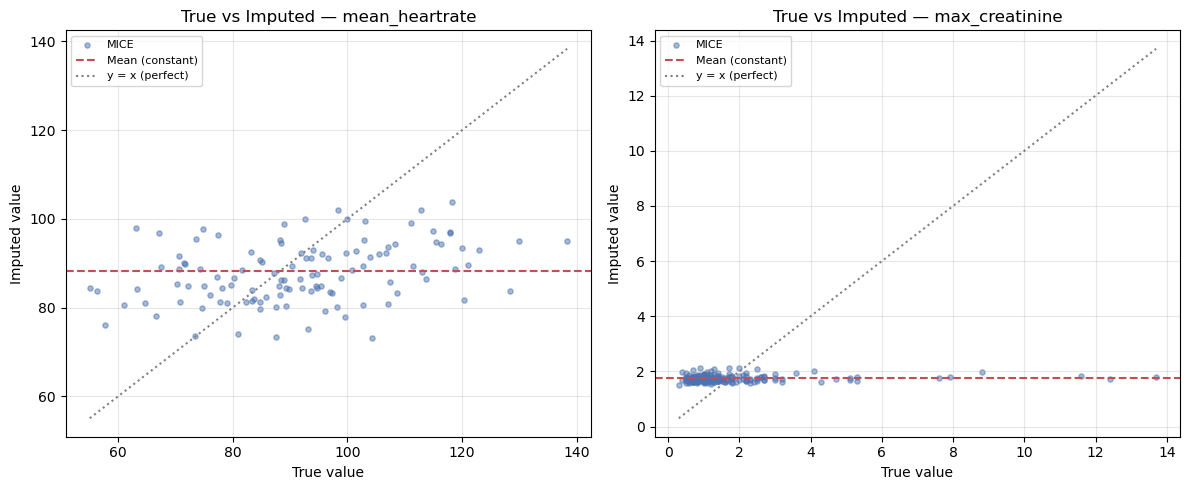

In [13]:
# === שלב 5ב: אמת מול ערך מושלם (ויזואליזציה) ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["mean_heartrate", "max_creatinine"]):
    mask = (df_original[col].notna() & df_missing[col].isna()).loc[X_test.index]
    idx = mask[mask].index
    true = df_original.loc[idx, col]
    ax.scatter(true, Ximp["MICE"]["test"].loc[idx, col],
               s=14, alpha=0.5, color="#4C72B0", label="MICE")
    ax.axhline(Ximp["Mean"]["test"].loc[idx, col].iloc[0],
               color="#C44E52", linestyle="--", label="Mean (constant)")
    lo, hi = true.min(), true.max()
    ax.plot([lo, hi], [lo, hi], color="gray", linestyle=":", label="y = x (perfect)")
    ax.set_title(f"True vs Imputed — {col}")
    ax.set_xlabel("True value"); ax.set_ylabel("Imputed value")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

<div dir="rtl">

**שאלה 5 — האם איכות ההשלמה הייתה אחידה בין שני המשתנים?**
לא. `mean_heartrate` שוחזר טוב יותר (MICE: קורלציה ~0.34) מ-`max_creatinine` (~0.14).
MICE עקף את Mean בשני המשתנים אך רק במעט, כי הקריאטינין כמעט אינו ניתן לחיזוי משאר המשתנים — וערכו האמיתי כמעט זהה בין צעירים למבוגרים, כך שאפילו ההטיה ב-MAR זניחה.

</div>

<div dir="rtl">

## שלב 6 — בניית מודל פרוגנוסטי

בונים שני מודלים, לכל אחת משתי שיטות ההשלמה — סה"כ **4 מודלים** (Mean/MICE × LogReg/RandomForest). כך נבדיל בין השפעת *סוג המודל* להשפעת *שיטת ההשלמה*.

**מניעת דליפה בתוך ה-Pipeline:** הקידוד (`OneHotEncoder`) והסקיילינג (`StandardScaler`) נלמדים על ה-train בלבד; קטגוריות נדירות (<10) מקובצות, וקטגוריה לא-מוכרת ב-test מטופלת ב-`handle_unknown='ignore'`.
**איזון מחלקות:** `class_weight='balanced'` בשני המודלים (בגלל ~25% חיוביים).
המודלים נשמרים בזיכרון ומשוחזרים זהה בכל הרצה בזכות `SEED` קבוע (אין צורך בקבצי pickle לא-ניידים).
**ללא משקול מחלקות:** חוסר האיזון מתון (~25%), ובחירת ברירת המחדל שומרת על קליברציה (הסתברות ממוצעת ≈ שיעור הבסיס), הקריטית לשלבים 7-8.

</div>

In [15]:
# === שלב 6: בניית 4 המודלים בתוך Pipeline תקין ===
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def build_pipeline(classifier, scale_numeric):
    """קדם-עיבוד (סקיילינג למספריים אם נדרש + one-hot לקטגוריאליים) ואז המסווג."""
    num_transformer = StandardScaler() if scale_numeric else "passthrough"
    prep = ColumnTransformer([
        ("num", num_transformer, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=10), cat_cols),
    ])
    return Pipeline([("prep", prep), ("clf", classifier)])

model_specs = {
    "LogReg": (LogisticRegression(max_iter=1000, random_state=SEED), True),
    "RandomForest": (RandomForestClassifier(n_estimators=300, random_state=SEED,
                                            n_jobs=-1), False),
}

trained = {}      # (שיטה, מודל) -> Pipeline מאומן
pred_prob = {}    # (שיטה, מודל) -> הסתברות חזויה על ה-test
for method in ["Mean", "MICE"]:
    for name, (clf, scale) in model_specs.items():
        pipe = build_pipeline(clone(clf), scale).fit(Ximp[method]["train"], y_train)
        trained[(method, name)] = pipe
        pred_prob[(method, name)] = pipe.predict_proba(Ximp[method]["test"])[:, 1]

trained_summary = pd.DataFrame(
    [{"שיטת השלמה": m, "מודל": n, "אומן על": f"{len(y_train)} רשומות"}
     for (m, n) in trained])
display(rtl(trained_summary))

שיטת השלמה,מודל,אומן על
Mean,LogReg,3419 רשומות
Mean,RandomForest,3419 רשומות
MICE,LogReg,3419 רשומות
MICE,RandomForest,3419 רשומות


<div dir="rtl">

**שאלה 6 — מה ההבדל העיקרי בין רגרסיה לוגיסטית למודל הנוסף? מדוע בחרנו בו?**
רגרסיה לוגיסטית היא מודל ליניארי-פרמטרי המניח קשר לוג-לינארי ומחזיר מקדמים פרשניים; RandomForest הוא אנסמבל עצים שלוכד קשרים לא-ליניאריים ואינטראקציות ללא הנחת ליניאריות.
בחרנו ב-RandomForest כי הוא משלים את הרגרסיה (בודק אם קיים מבנה לא-ליניארי), מובנה ב-scikit-learn ללא התקנה נוספת, ועמיד לסקיילינג ולחריגים.

</div>

<div dir="rtl">

## שלב 7 — הערכת ביצועי המודלים

מחשבים לכל אחד מ-4 המודלים: **ROC-AUC** ו-**PR-AUC** (דיסקרימינציה/דירוג), **Brier Score** (איכות הסתברות, נמוך=טוב), ו-**Precision/Recall** בסף 0.5.
*הערה:* Recall נמוך בסף 0.5 כי שיעור הבסיס ~25% והמודל ממעט להגיע מעל 0.5 — מה שמדגיש את חשיבות דירוג הסיכונים (שלב 8) על פני סף יחיד.
מציגים עקומות ROC, Precision-Recall, ו-Calibration.

</div>

In [16]:
# === שלב 7א: טבלת מדדי ביצוע (4 מודלים) ===
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             precision_score, recall_score, roc_curve,
                             precision_recall_curve)
from sklearn.calibration import calibration_curve

THRESHOLD = 0.5
rows = []
for (method, name), p in pred_prob.items():
    pred = (p >= THRESHOLD).astype(int)
    rows.append({
        "מודל": f"{name} ({method})",
        "ROC-AUC": round(roc_auc_score(y_test, p), 3),
        "PR-AUC": round(average_precision_score(y_test, p), 3),
        "Brier": round(brier_score_loss(y_test, p), 3),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "Recall": round(recall_score(y_test, pred), 3),
    })
metrics_table = pd.DataFrame(rows)
display(rtl(metrics_table))

מודל,ROC-AUC,PR-AUC,Brier,Precision,Recall
LogReg (Mean),0.754000,0.466000,0.160000,0.541000,0.140000
RandomForest (Mean),0.770000,0.473000,0.157000,0.529000,0.126000
LogReg (MICE),0.754000,0.467000,0.160000,0.547000,0.144000
RandomForest (MICE),0.775000,0.484000,0.156000,0.565000,0.123000


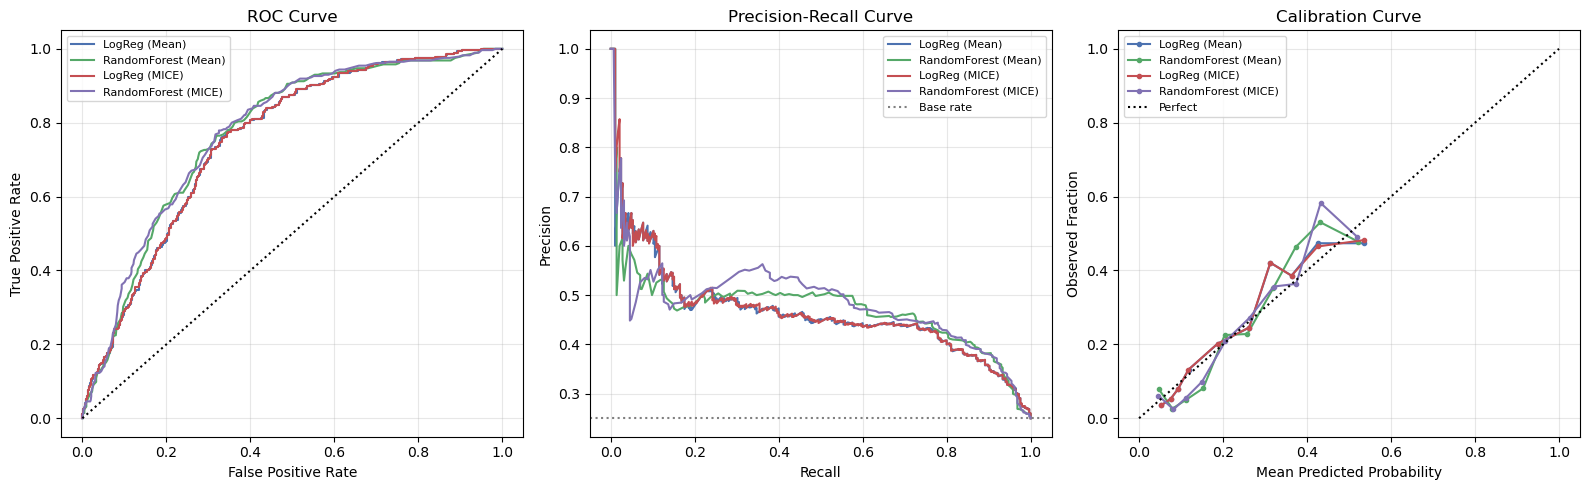

In [17]:
# === שלב 7ב: עקומות ROC, PR, Calibration ===
colors = {("Mean", "LogReg"): "#4C72B0", ("Mean", "RandomForest"): "#55A868",
          ("MICE", "LogReg"): "#C44E52", ("MICE", "RandomForest"): "#8172B3"}
def lbl(key):
    return f"{key[1]} ({key[0]})"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for key, p in pred_prob.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=colors[key], label=lbl(key))
axes[0].plot([0, 1], [0, 1], "k:")
axes[0].set_title("ROC Curve"); axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate"); axes[0].legend(fontsize=8)

for key, p in pred_prob.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, color=colors[key], label=lbl(key))
axes[1].axhline(y_test.mean(), color="gray", linestyle=":", label="Base rate")
axes[1].set_title("Precision-Recall Curve"); axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision"); axes[1].legend(fontsize=8)

for key, p in pred_prob.items():
    frac, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    axes[2].plot(mean_pred, frac, marker="o", markersize=3, color=colors[key], label=lbl(key))
axes[2].plot([0, 1], [0, 1], "k:", label="Perfect")
axes[2].set_title("Calibration Curve"); axes[2].set_xlabel("Mean Predicted Probability")
axes[2].set_ylabel("Observed Fraction"); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

<div dir="rtl">

**שאלה 7 — האם מודל עם discrimination טוב היה גם מכויל היטב?**
הדיסקרימינציה בינונית בכל המודלים (ROC-AUC ~0.75-0.78), ו-RandomForest מעט עדיף.
עם משקלים רגילים הקליברציה סבירה (Brier ~0.16, הסתברות ממוצעת ≈ שיעור הבסיס), אך העקומה סוטה בקצה העליון הדליל.
מסקנה: דיסקרימינציה טובה אינה מבטיחה קליברציה — אלו תכונות נפרדות (ראינו ש-`balanced` ניפח הסתברויות ופגע ב-Brier).

</div>

<div dir="rtl">

## שלב 8 — דירוג סיכונים (Risk Stratification)

מחלקים את מטופלי ה-test לשלוש שכבות לפי הסיכון החזוי: **נמוך (<0.3)**, **בינוני (0.3-0.7)**, **גבוה (>0.7)**.
לכל שכבה: n, אחוז מהמטופלים, הסיכון החזוי הממוצע, ושיעור התוצאה הנצפה בפועל.
המודל הראשי לדירוג: **RandomForest (MICE)** — בעל הדיסקרימינציה הטובה ביותר; הרגרסיה הלוגיסטית נותנת הפרדה כמעט זהה.

</div>

In [18]:
# === שלב 8א: טבלת דירוג סיכונים ===
RISK_BINS = [0, 0.3, 0.7, 1.0000001]
RISK_LABELS = ["Low (<0.3)", "Medium (0.3-0.7)", "High (>0.7)"]

def risk_table(probs, y_true):
    tiers = pd.cut(probs, bins=RISK_BINS, right=False, labels=RISK_LABELS)
    d = pd.DataFrame({"tier": tiers, "p": probs, "y": np.asarray(y_true)})
    g = d.groupby("tier", observed=False)
    n = g.size().to_numpy()
    pred = g["p"].mean().to_numpy()
    obs = g["y"].mean().to_numpy()
    return pd.DataFrame({
        "שכבת סיכון": RISK_LABELS,
        "n (קבוצה)": n,
        "אחוז מהמטופלים": [f"{v / len(d) * 100:.1f}%" for v in n],
        "סיכון חזוי ממוצע": [f"{v:.3f}" if not np.isnan(v) else "—" for v in pred],
        "שיעור תוצאה נצפה": [f"{v * 100:.1f}%" if not np.isnan(v) else "—" for v in obs],
    })

PRIMARY = ("MICE", "RandomForest")
strat = risk_table(pred_prob[PRIMARY], y_test)
display(rtl(strat))

שכבת סיכון,n (קבוצה),אחוז מהמטופלים,סיכון חזוי ממוצע,שיעור תוצאה נצפה
Low (<0.3),694,60.9%,0.144,12.1%
Medium (0.3-0.7),446,39.1%,0.413,45.1%
High (>0.7),0,0.0%,—,—


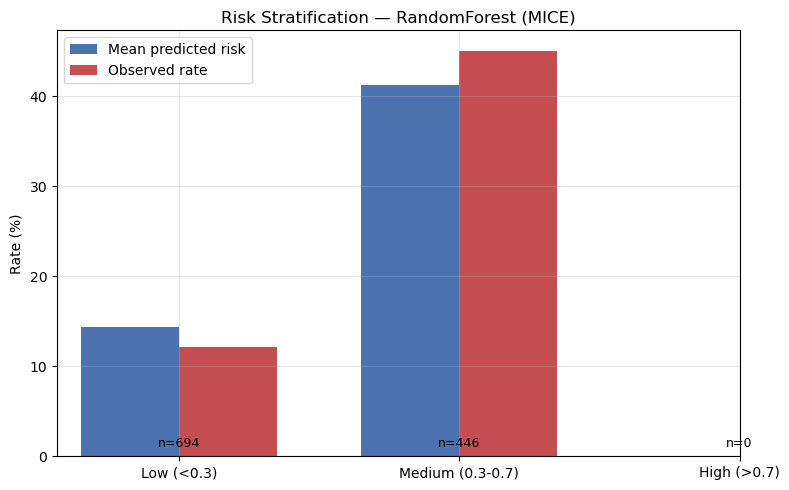

In [19]:
# === שלב 8ב: סיכון חזוי מול שיעור נצפה לכל שכבה ===
probs = pred_prob[PRIMARY]
tiers = pd.cut(probs, bins=RISK_BINS, right=False, labels=RISK_LABELS)
agg = (pd.DataFrame({"tier": tiers, "p": probs, "y": np.asarray(y_test)})
       .groupby("tier", observed=False)
       .agg(pred=("p", "mean"), obs=("y", "mean"), n=("y", "size")))

x = np.arange(len(RISK_LABELS)); w = 0.35
fig, ax = plt.subplots()
ax.bar(x - w/2, agg["pred"] * 100, w, label="Mean predicted risk", color="#4C72B0")
ax.bar(x + w/2, agg["obs"] * 100, w, label="Observed rate", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(RISK_LABELS)
ax.set_ylabel("Rate (%)"); ax.set_title("Risk Stratification — RandomForest (MICE)")
for i, n in enumerate(agg["n"]):
    ax.text(i, 1, f"n={n}", ha="center", fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()

<div dir="rtl">

**שאלה 8 — האם התקבלה הפרדה ברורה בין השכבות? האם הדירוג שימושי קלינית?**
כן, הפרדה ברורה בין השכבות המאוכלסות: השיעור הנצפה עולה מ-~12% (Low) ל-~45% (Medium), והחיזוי תואם את הנצפה (קליברציה טובה בתוך שכבה).
השכבה High (>0.7) ריקה כמעט לחלוטין כי המודל אינו מגיע מעל 0.7 — התוצאה ניתנת לחיזוי בינוני בלבד.
הדירוג שימושי להבחנה בין סיכון נמוך למוגבר, אך הסף 0.7 גבוה מדי למודל זה; ספים מבוססי-נתונים (טרציות) היו מתאימים יותר.

</div>

<div dir="rtl">

## שלב 9 — מסקנות וחשיבה ביקורתית

מבססים כל מסקנה על התוצאות שהוצגו: השוואת השפעת ההשלמה על הביצועים ועל הדירוג, ולאחריה ארבע שאלות הסיכום.

</div>

In [20]:
# === שלב 9א: השפעת שיטת ההשלמה על הביצועים ===
perf_rows = []
for name in ["LogReg", "RandomForest"]:
    rm, ri = pred_prob[("Mean", name)], pred_prob[("MICE", name)]
    perf_rows.append({
        "מודל": name,
        "ROC-AUC (Mean)": round(roc_auc_score(y_test, rm), 3),
        "ROC-AUC (MICE)": round(roc_auc_score(y_test, ri), 3),
        "PR-AUC (Mean)": round(average_precision_score(y_test, rm), 3),
        "PR-AUC (MICE)": round(average_precision_score(y_test, ri), 3),
    })
display(rtl(pd.DataFrame(perf_rows)))

# === שלב 9ב: השפעת ההשלמה על דירוג הסיכונים (RandomForest) ===
strat_cmp = pd.DataFrame({"שכבת סיכון": RISK_LABELS})
for method in ["Mean", "MICE"]:
    rt = risk_table(pred_prob[(method, "RandomForest")], y_test)
    strat_cmp[f"n ({method})"] = rt["n (קבוצה)"].values
    strat_cmp[f"נצפה ({method})"] = rt["שיעור תוצאה נצפה"].values
display(rtl(strat_cmp))

מודל,ROC-AUC (Mean),ROC-AUC (MICE),PR-AUC (Mean),PR-AUC (MICE)
LogReg,0.754000,0.754000,0.466000,0.467000
RandomForest,0.770000,0.775000,0.473000,0.484000


שכבת סיכון,n (Mean),נצפה (Mean),n (MICE),נצפה (MICE)
Low (<0.3),702,11.8%,694,12.1%
Medium (0.3-0.7),438,46.1%,446,45.1%
High (>0.7),0,—,0,—


<div dir="rtl">

### תשובות הסיכום

**א. האם איכות ההשלמה השפיעה על ביצועי המודל?**
כמעט לא. ברגרסיה ה-ROC-AUC זהה (0.754), וב-RandomForest השיפור מזערי (0.770→0.775). הסיבה: רק שני משתנים הושלמו והם תורמים מעט לחיזוי.

**ב. האם איכות ההשלמה השפיעה על דירוג הסיכונים?**
לא באופן ניכר. חלוקת השכבות ושיעורי התוצאה הנצפים כמעט זהים בין Mean ל-MICE (Low ~12%, Medium ~45%).

**ג. האם מודל טוב יותר סטטיסטית היה גם שימושי יותר קלינית?**
לא בהכרח. RandomForest מעט עדיף סטטיסטית (ROC 0.775 מול 0.754), אך הקליברציה והדירוג דומים מאוד; הרגרסיה פרשנית יותר, כך שהיתרון הסטטיסטי הקטן אינו מתורגם ליתרון קליני ברור.

**ד. גורמים שעלולים לפגוע במהימנות (דליפה/הטיה)?**
דליפה נמנעה: פיצול-תחילה, השלמה+קידוד שנלמדו על train בלבד בתוך Pipeline, והשמטת `icu_los`.
סיכונים שנותרו: פיצול יחיד (שונות באומדן — CV/bootstrap עדיפים), אוכלוסיית MIMIC צרה ולא-מאוזנת אתנית (הכללה מוגבלת), וסף המטרה (אחוזון 75) תלוי-מדגם.

</div>